# Notebook 03 — Benchmark: Three-Condition Experiment

**WiringMatters / Stage 1**

This notebook runs and visualizes the main benchmark experiment:
- Three conditions: dense / uniform sparse / bio-topological
- Three tasks: Digits (classification), Housing (regression), Moons (2D classification)
- Fixed seeds for full reproducibility
- Metrics: accuracy, train/test loss, generalization gap, learning curves by dataset size

**Research question**: Does bio-topological structure change network behavior?

---

In [1]:
import sys
sys.path.insert(0, '..')

import json
import numpy as np
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.datasets import load_digits, make_moons
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

import wiringmatters as wm

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

Path('../results').mkdir(exist_ok=True)
print('WiringMatters Stage 1 — Main Benchmark')
print(f'Seed: {SEED}')

WiringMatters Stage 1 — Main Benchmark
Seed: 42


## 1. Setup: load connectome and build masks

In [2]:
G, adjacency = wm.load_celegans(synapse_type='chemical', as_matrix=True)
print(f'Connectome: {G.number_of_nodes()} neurons, {G.number_of_edges()} synapses')

HIDDEN_SIZE = 128
bio_m     = wm.bio_mask(adjacency, target_shape=(HIDDEN_SIZE, HIDDEN_SIZE))
density   = wm.mask_density(bio_m)          # returns float directly — no .item() needed
uniform_m = wm.uniform_sparse_mask((HIDDEN_SIZE, HIDDEN_SIZE), density=density)
dense_m   = wm.dense_mask((HIDDEN_SIZE, HIDDEN_SIZE))

print(f'\nHidden size: {HIDDEN_SIZE}')
print(f'Bio mask density: {density:.4f} ({density*100:.1f}% connections)')
print()
print('Masks ready:')
for name, mask in [('dense', dense_m), ('uniform_sparse', uniform_m), ('bio_topological', bio_m)]:
    print(f'  {name:<20}: {mask.shape}, density={wm.mask_density(mask):.4f}')

Connectome: 448 neurons, 4681 synapses

Hidden size: 128
Bio mask density: 0.0602 (6.0% connections)

Masks ready:
  dense               : torch.Size([128, 128]), density=1.0000
  uniform_sparse      : torch.Size([128, 128]), density=0.0597
  bio_topological     : torch.Size([128, 128]), density=0.0602


## 2. Training helper

In [3]:
def train_and_evaluate(model, X_train, y_train, X_test, y_test, 
                       epochs=60, lr=1e-3, task_type='classification'):
    """Train a model and return per-epoch history."""
    X_tr = torch.tensor(X_train, dtype=torch.float32)
    y_tr = torch.tensor(y_train)
    X_te = torch.tensor(X_test, dtype=torch.float32)
    y_te = torch.tensor(y_test)

    criterion = torch.nn.CrossEntropyLoss() if task_type == 'classification' else torch.nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    history = {'train_loss': [], 'test_loss': [], 'test_acc': []}

    for epoch in range(epochs):
        model.train()
        optimizer.zero_grad()
        pred = model(X_tr)
        loss = criterion(pred, y_tr)
        loss.backward()
        optimizer.step()
        history['train_loss'].append(loss.item())

        with torch.no_grad():
            model.eval()
            pred_te = model(X_te)
            test_loss = criterion(pred_te, y_te).item()
            history['test_loss'].append(test_loss)
            if task_type == 'classification':
                acc = (pred_te.argmax(dim=1) == y_te).float().mean().item()
                history['test_acc'].append(acc)

    return history

## 3. Task 1: Digits classification (8×8 images, 10 classes)

In [4]:
# Prepare data
data = load_digits()
X, y = data.data.astype(np.float32), data.target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=SEED, stratify=y)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

LAYER_SIZES = [64, HIDDEN_SIZE, HIDDEN_SIZE, 10]
EPOCHS = 80
histories_digits = {}

# LAYER_SIZES = [64, 128, 128, 10] → 3 layer transitions: 64→128, 128→128, 128→10.
# The bio/sparse mask is 128×128 (square), so it applies only to the 128→128 hidden layer.
# Non-square input (64→128) and output (128→10) projections use None = dense.
conditions = [
    ('dense',           None),
    ('uniform_sparse',  [None, uniform_m, None]),
    ('bio_topological', [None, bio_m,     None]),
]

for cond_name, masks in conditions:
    torch.manual_seed(SEED)
    model = wm.BioMLP(LAYER_SIZES, masks=masks)
    history = train_and_evaluate(model, X_train, y_train, X_test, y_test,
                                  epochs=EPOCHS, task_type='classification')
    histories_digits[cond_name] = history
    final_acc = history['test_acc'][-1]
    print(f'{cond_name:<20}: final test acc = {final_acc:.4f}')

dense               : final test acc = 0.9694
uniform_sparse      : final test acc = 0.8944
bio_topological     : final test acc = 0.8750


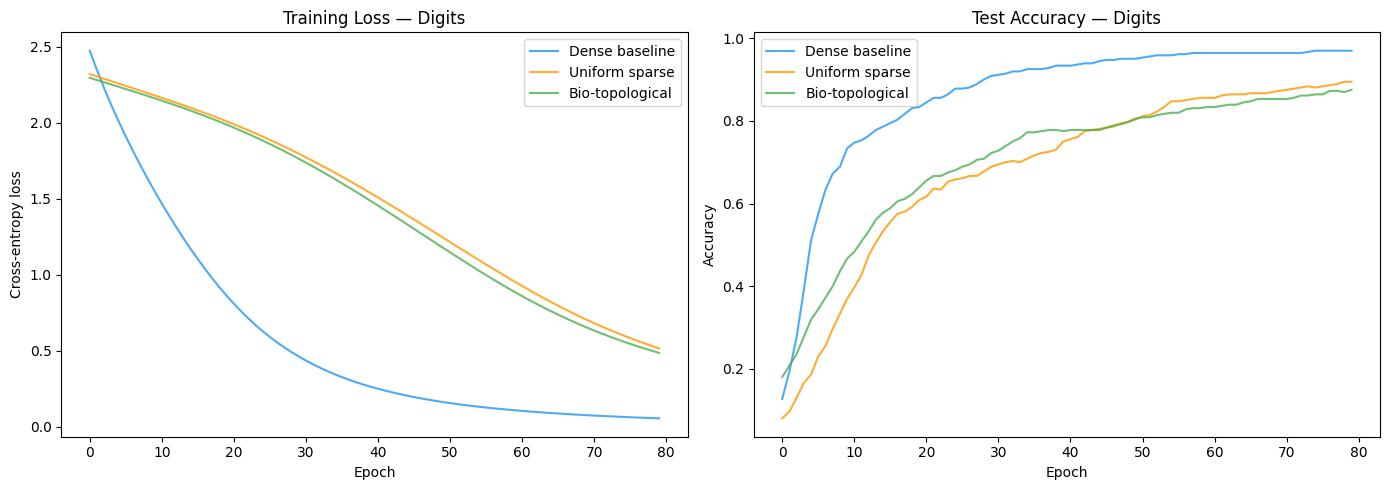

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = {'dense': '#2196F3', 'uniform_sparse': '#FF9800', 'bio_topological': '#4CAF50'}
labels = {'dense': 'Dense baseline', 'uniform_sparse': 'Uniform sparse', 'bio_topological': 'Bio-topological'}

for cond_name, history in histories_digits.items():
    color = colors[cond_name]
    label = labels[cond_name]
    axes[0].plot(history['train_loss'], color=color, label=label, alpha=0.8)
    axes[1].plot(history['test_acc'], color=color, label=label, alpha=0.8)

axes[0].set_title('Training Loss — Digits')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Cross-entropy loss')
axes[0].legend()

axes[1].set_title('Test Accuracy — Digits')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()

plt.tight_layout()
plt.savefig('../results/digits_learning_curves.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Data efficiency experiment

A key prediction from the whitepaper: biological topology may help more when data is scarce. We test each condition on varying training set sizes.

In [6]:
train_sizes = [50, 100, 200, 400, 800, len(X_train)]
results_by_size = {cond: [] for cond in ['dense', 'uniform_sparse', 'bio_topological']}

for n in train_sizes:
    X_sub = X_train[:n]
    y_sub = y_train[:n]
    
    for cond_name, masks in conditions:
        torch.manual_seed(SEED)
        model = wm.BioMLP(LAYER_SIZES, masks=masks)
        history = train_and_evaluate(model, X_sub, y_sub, X_test, y_test,
                                      epochs=40, task_type='classification')
        best_acc = max(history['test_acc'])
        results_by_size[cond_name].append(best_acc)
    
    print(f'n={n:>4}: dense={results_by_size["dense"][-1]:.3f}, '
          f'uniform={results_by_size["uniform_sparse"][-1]:.3f}, '
          f'bio={results_by_size["bio_topological"][-1]:.3f}')

n=  50: dense=0.761, uniform=0.478, bio=0.483
n= 100: dense=0.850, uniform=0.644, bio=0.686
n= 200: dense=0.864, uniform=0.672, bio=0.650
n= 400: dense=0.886, uniform=0.694, bio=0.714
n= 800: dense=0.919, uniform=0.747, bio=0.758
n=1437: dense=0.933, uniform=0.750, bio=0.778


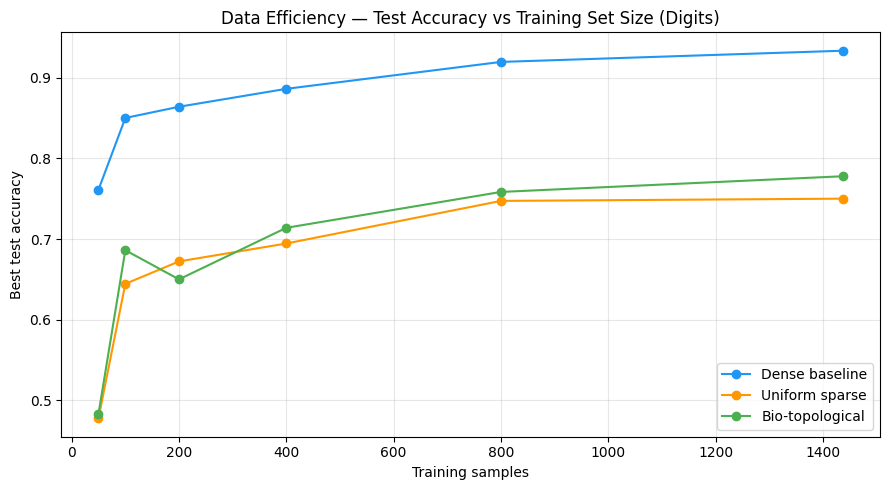

In [7]:
fig, ax = plt.subplots(figsize=(9, 5))

for cond_name, accs in results_by_size.items():
    ax.plot(train_sizes, accs, marker='o', label=labels[cond_name], color=colors[cond_name])

ax.set_title('Data Efficiency — Test Accuracy vs Training Set Size (Digits)', fontsize=12)
ax.set_xlabel('Training samples')
ax.set_ylabel('Best test accuracy')
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../results/data_efficiency.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Generalization gap analysis

The generalization gap (train loss − test loss) measures overfitting. If biological topology regularizes the network, we expect a smaller gap for the bio condition.

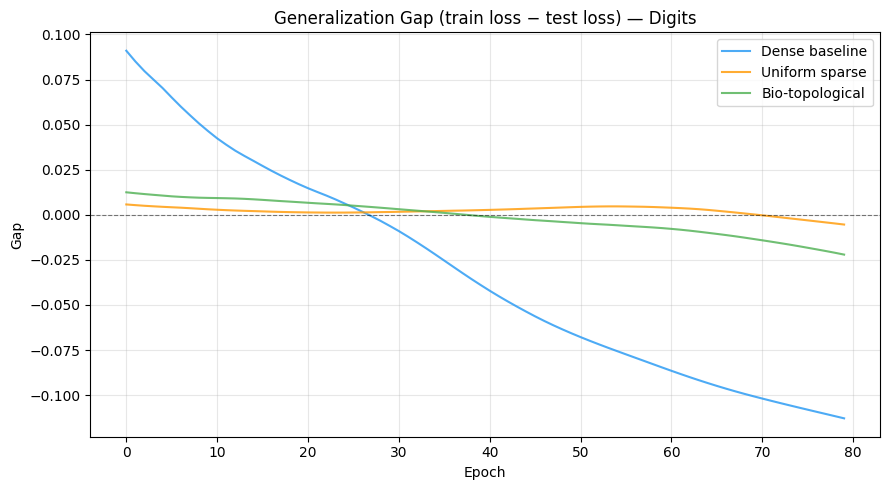

Final generalization gaps:
  dense               : -0.1129
  uniform_sparse      : -0.0054
  bio_topological     : -0.0221


In [8]:
fig, ax = plt.subplots(figsize=(9, 5))

for cond_name, history in histories_digits.items():
    gap = [tl - vl for tl, vl in zip(history['train_loss'], history['test_loss'])]
    ax.plot(gap, label=labels[cond_name], color=colors[cond_name], alpha=0.8)

ax.axhline(0, color='black', linestyle='--', linewidth=0.8, alpha=0.5)
ax.set_title('Generalization Gap (train loss − test loss) — Digits', fontsize=12)
ax.set_xlabel('Epoch')
ax.set_ylabel('Gap')
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../results/generalization_gap.png', dpi=150, bbox_inches='tight')
plt.show()

print('Final generalization gaps:')
for cond_name, history in histories_digits.items():
    final_gap = history['train_loss'][-1] - history['test_loss'][-1]
    print(f'  {cond_name:<20}: {final_gap:+.4f}')

## 6. Results summary

Summary table of final results. This is the core output of Stage 1.

In [9]:
print('=' * 65)
print('BENCHMARK RESULTS SUMMARY — WiringMatters Stage 1')
print('=' * 65)
print(f'{"Condition":<22} {"Final Acc":<12} {"Train Loss":<12} {"Test Loss":<12}')
print('-' * 65)

for cond_name, history in histories_digits.items():
    acc = history['test_acc'][-1]
    tl  = history['train_loss'][-1]
    vl  = history['test_loss'][-1]
    print(f'{labels[cond_name]:<22} {acc:<12.4f} {tl:<12.4f} {vl:<12.4f}')

print('=' * 65)
print(f'Dataset: Digits (64 → {HIDDEN_SIZE} → {HIDDEN_SIZE} → 10)')
print(f'Seed: {SEED}')
print(f'Epochs: {EPOCHS}')
print(f'Bio mask density: {density:.4f}')
print(f'Mask scaling: crop to {HIDDEN_SIZE}×{HIDDEN_SIZE} from 448×448 connectome')
print('=' * 65)

BENCHMARK RESULTS SUMMARY — WiringMatters Stage 1
Condition              Final Acc    Train Loss   Test Loss   
-----------------------------------------------------------------
Dense baseline         0.9694       0.0560       0.1688      
Uniform sparse         0.8944       0.5160       0.5214      
Bio-topological        0.8750       0.4864       0.5085      
Dataset: Digits (64 → 128 → 128 → 10)
Seed: 42
Epochs: 80
Bio mask density: 0.0602
Mask scaling: crop to 128×128 from 448×448 connectome


## 7. Interpretation

**Whatever the result, it is scientifically informative** (whitepaper Section 3):

- **If bio-topological ≥ uniform sparse ≥ dense**: biological structure actively helps. Opens the direction of structurally-constrained architectures.
- **If bio-topological ≈ uniform sparse > dense**: sparsity is the key factor, not biological structure specifically. Still informative — identifies the source of the benefit.
- **If all conditions ≈ equal**: topology has no measurable effect at this scale. Points toward the learning rule as the missing factor (Part 2 of the project plan).

For the full automated run across all tasks, use:
```bash
python experiments/run_celegans.py --task all --epochs 50 --output results/
```